# 07_降维技术-因子分析

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 补齐 PCA 导入。模拟数据的各列原本独立，载荷仅用于演示，不能据此认定“学习能力”“社交活跃度”等真实潜因子。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊降维技术中的因子分析\~

因子分析其实就是通过一种数学方法，帮助我们从复杂的数据中找出一些更简单的规律，或者说找出“隐藏”在数据背后的重要因素。这些隐藏的因素，我们叫它“因子”。

#### 为什么需要因子分析？

当你有一个超复杂的数据集，比如一堆关于学生的各种信息（成绩、身高、体重、家庭背景等等）。每一个学生的数据项可能很多，如果我们希望简化这些数据，理解学生的整体情况，或者去除掉一些不必要的细节，因子分析就能帮助我们把这些复杂的信息“压缩”成更少、更有代表性的几个重要因素。

#### 举个简单的例子

假设你有一个关于学生的数据库，包括以下几个方面：

- 数学成绩
- 语文成绩
- 英语成绩
- 课外活动参与度
- 体育成绩

这些数据看起来有点复杂，但我们可能会发现，数学成绩、语文成绩、英语成绩之间其实有相似性，可能都代表了学生的“学习能力”；而课外活动参与度和体育成绩可能反映了学生的“活跃程度”。通过因子分析，我们可以把这些原本多维的数据（像五个成绩）归纳成两个因子：一个是“学习能力”，一个是“活跃程度”。

#### 基本步骤

1. **数据收集**：收集好你需要分析的各种数据。
2. **相关性分析**：看这些数据之间有没有相互关系，比如成绩之间、体育和课外活动的关系。
3. **提取因子**：从这些复杂的数据中提取出少数几个最重要的因子。因子分析会找到这些“隐藏”的因素。
4. **命名和解释**：根据提取出的因子，给它们一个容易理解的名字（比如“学习能力”或者“活跃程度”）。

总的来说，因子分析就是通过把复杂的数据“压缩”成更少的几个重要因素，来帮助我们更好地理解和分析数据。就像是我们把一堆杂乱的信息总结成更少、更有意义的“标签”，让我们能够更清楚地看到数据背后的规律。

## 原理详解

因子分析的核心目的是通过对数据进行建模，假设观测数据是由少数潜在的因子和误差项共同决定的。每个观测变量都可以通过一个线性组合来表示，组合中包含了几个共同因子和一个独立的误差项。

#### 数学模型：

假设我们有 $m$个观测变量（$x_1, x_2, \dots, x_m$），每个观测变量可以通过 $k$个潜在因子（$f_1, f_2, \dots, f_k$）和一个误差项（$\epsilon_1, \epsilon_2, \dots, \epsilon_m$）来表示：


$$
X = \Lambda F + \epsilon
$$


其中：

- $X$是一个 $m \times 1$的观测变量向量。
- $\Lambda$是一个 $m \times k$的因子载荷矩阵，它包含了因子对每个观测变量的贡献。
- $F$是一个 $k \times 1$的潜在因子向量。
- $\epsilon$是一个 $m \times 1$的误差项向量，表示每个观测变量中无法通过因子解释的部分。

### 因子分析数学原理

#### 目标和假设

因子分析的目标是通过估计因子载荷矩阵 $\Lambda$和误差项 $\epsilon$来对观测数据 $X$进行建模。为了简化问题，我们通常假设：

- 潜在因子 $F$是独立且标准正态分布的，即 $E[F] = 0$和 $\text{Cov}(F) = I_k$（单位矩阵）。
- 误差项 $\epsilon$与潜在因子 $F$不相关，即 $\text{Cov}(F, \epsilon) = 0$。
- 误差项的协方差矩阵 $\Psi$是对角矩阵，即 $\text{Cov}(\epsilon) = \Psi$。

#### 观测变量的协方差矩阵

假设我们已知观测变量的协方差矩阵 $\Sigma_X$，通过模型 $X = \Lambda F + \epsilon$，我们可以推导出协方差矩阵的表达式：


$$
\Sigma_X = \text{Cov}(X) = \Lambda \text{Cov}(F) \Lambda^T + \text{Cov}(\epsilon)
$$


由于 $\text{Cov}(F) = I_k$且 $\text{Cov}(\epsilon) = \Psi$，因此协方差矩阵为：


$$
\Sigma_X = \Lambda \Lambda^T + \Psi
$$


这里的 $\Sigma_X$是观测数据 $X$的协方差矩阵，$\Lambda \Lambda^T$表示因子部分的协方差，$\Psi$则是误差部分的协方差矩阵。

#### 因子载荷矩阵的估计

为了进行因子分析，我们的目标是估计因子载荷矩阵 $\Lambda$和误差协方差矩阵 $\Psi$。常用的估计方法是最大似然估计（MLE）。

我们根据观测数据 $X$的协方差矩阵 $\Sigma_X$，通过最大化对数似然函数来估计这些参数。

最大似然估计的对数似然函数为：


$$
\mathcal{L}(\Lambda, \Psi) = -\frac{n}{2} \left[ \log|\Sigma_X| + \text{tr}(\Sigma_X^{-1} S) \right]
$$


其中，$n$是样本的数量，$S$是样本协方差矩阵，$\Sigma_X$是我们通过因子分析模型预测出的协方差矩阵。

#### 旋转操作

在因子分析中，因子载荷矩阵 $\Lambda$可以通过旋转来优化。旋转的目的是使得因子更加容易解释。旋转可以通过**正交旋转**（如 Varimax 旋转）或**斜交旋转**（如 Promax 旋转）来完成。

旋转的过程实际上是通过对因子载荷矩阵 $\Lambda$进行线性变换来改变因子间的关系，使得每个因子在某些观测变量上有较强的载荷（即更能解释这些变量），而在其他变量上则没有太大影响。

### 3. 因子分析的算法流程

1. **标准化数据**：在因子分析之前，通常需要对观测数据进行标准化处理，以确保每个变量有相同的权重。标准化后，数据的均值为 0，方差为 1。
2. **计算协方差矩阵**：根据标准化后的数据，计算协方差矩阵 $\Sigma_X$。
3. **估计因子载荷矩阵**：使用最大似然估计（MLE）或主成分分析（PCA）等方法来初步估计因子载荷矩阵 $\Lambda$。
4. **旋转因子载荷矩阵**：如果需要，更进一步地通过旋转方法来优化因子载荷矩阵，使得因子更容易解释。
5. **选择因子数量**：通过碎石图（Scree Plot）等方法，确定因子的数量 $k$。通常通过选择特征值大于 1 的因子，或者根据方差贡献的比例来确定。
6. **提取因子**：通过因子载荷矩阵 $\Lambda$提取潜在因子 $F$，即将原始观测数据映射到因子空间。
7. **解释和验证**：根据因子载荷矩阵对因子进行命名和解释。最后，通过重构数据或进行验证，确保模型的有效性。

## 完整案例

假设我们有一组关于学生学业和行为的数据集，包含了不同学科的成绩、课外活动的参与程度、体育活动的参与情况等。我们的任务是利用因子分析找出影响学生表现的潜在因子（例如：学习能力、社交活跃度、运动能力等）。

#### 数据准备

首先，我们需要一个模拟数据集，包含以下字段：

- `Math_score`：数学成绩
- `Science_score`：科学成绩
- `English_score`：英语成绩
- `Art_score`：艺术成绩
- `Sport_participation`：体育活动参与度
- `Social_activity`：社交活动参与度

这些数据将用于应用因子分析，提取潜在因子。

   Math_score  Science_score  English_score  Art_score  Sport_participation  \
0   86.748141      77.309109      77.034458  66.609176            55.224294   
1   56.210191      77.469983      70.314474  61.093212            54.249854   
2   71.722049     106.825129      62.701396  68.456782            35.952202   
3   74.583400      89.711731      66.300007  62.048192            58.693763   
4   75.159087     109.767811      72.742828  68.747775            27.648760   

   Social_activity  
0        46.423676  
1        58.732107  
2        71.537685  
3        60.686515  
4        69.390889  
   Math_score  Science_score  English_score  Art_score  Sport_participation  \
0    1.138895      -0.232743       0.849871   0.308379             0.348170   
1   -1.916056      -0.219533       0.008415  -0.796734             0.283049   
2   -0.364283       2.190799      -0.944871   0.678543            -0.939762   
3   -0.078039       0.785629      -0.494264  -0.605406             0.580031   
4   

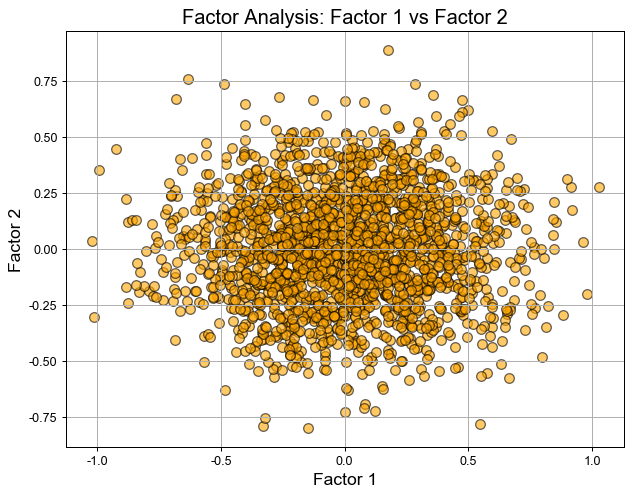

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_spd_matrix

np.random.seed(42)
n_samples = 2000
n_features = 6

# 创建一个模拟的数据集：成绩和活动参与情况
data = np.random.normal(size=(n_samples, n_features))
data[:, 0] = np.random.normal(75, 10, size=n_samples)  # Math_score
data[:, 1] = np.random.normal(80, 12, size=n_samples)  # Science_score
data[:, 2] = np.random.normal(70, 8, size=n_samples)   # English_score
data[:, 3] = np.random.normal(65, 5, size=n_samples)   # Art_score
data[:, 4] = np.random.normal(50, 15, size=n_samples)  # Sport_participation
data[:, 5] = np.random.normal(60, 10, size=n_samples)  # Social_activity

# 将数据转换为 DataFrame 以便于分析
columns = ['Math_score', 'Science_score', 'English_score', 'Art_score', 'Sport_participation', 'Social_activity']
df = pd.DataFrame(data, columns=columns)

# 显示前五行数据
print(df.head())

# 数据预处理：标准化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 显示标准化后的数据
print(pd.DataFrame(scaled_data, columns=columns).head())

# 2. 使用因子分析进行降维

# 定义因子分析模型，假设我们提取2个因子
factor_analyzer = FactorAnalysis(n_components=2, random_state=42)
factor_scores = factor_analyzer.fit_transform(scaled_data)

# 显示因子得分
factor_df = pd.DataFrame(factor_scores, columns=['Factor_1', 'Factor_2'])
print(factor_df.head())

# 可视化：因子得分的散点图
plt.figure(figsize=(8, 6))
plt.scatter(factor_df['Factor_1'], factor_df['Factor_2'], alpha=0.6, c='orange', edgecolors='black', s=60)
plt.title('Factor Analysis: Factor 1 vs Factor 2', fontsize=16)
plt.xlabel('Factor 1', fontsize=14)
plt.ylabel('Factor 2', fontsize=14)
plt.grid(True)
plt.show()

                     Factor_1  Factor_2
Math_score           0.268996 -0.000705
Science_score        0.103530 -0.145504
English_score       -0.066822 -0.063298
Art_score            0.162338 -0.000430
Sport_participation -0.051040 -0.197789
Social_activity      0.033479  0.031532


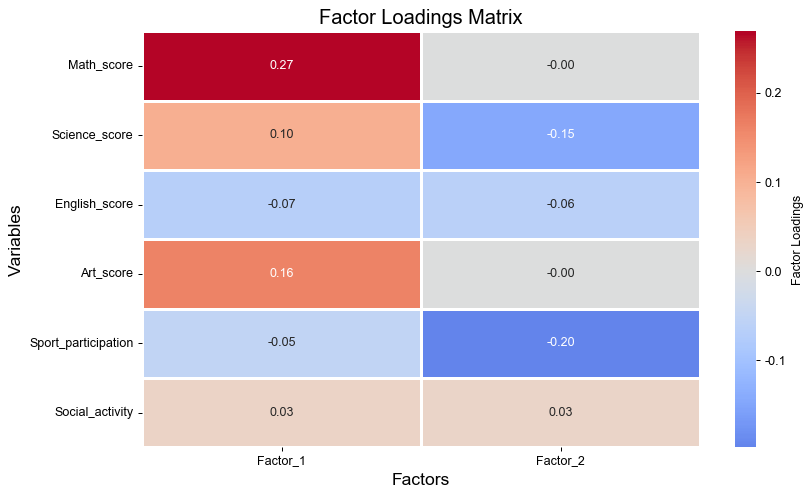

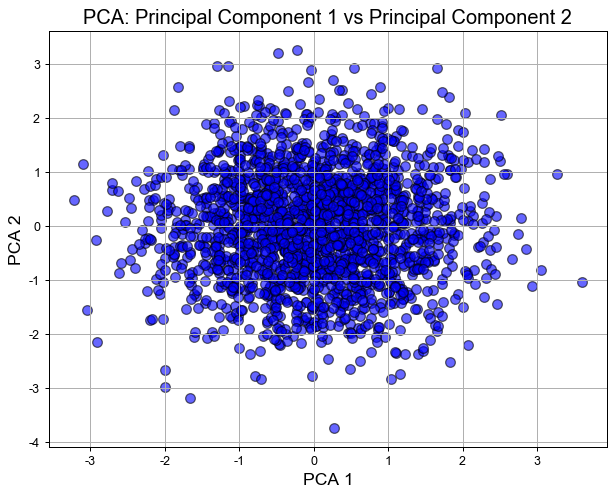

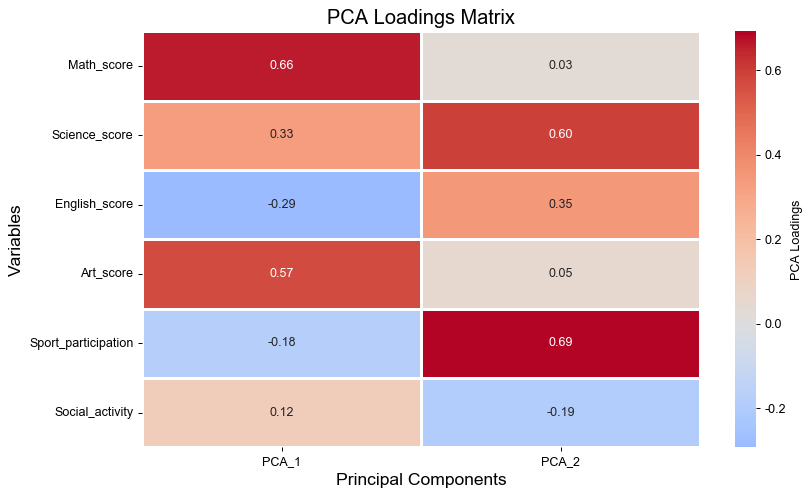

In [3]:
# 3. 解释因子分析的结果

# 查看因子载荷矩阵
loadings = factor_analyzer.components_.T
loadings_df = pd.DataFrame(loadings, columns=['Factor_1', 'Factor_2'], index=columns)
print(loadings_df)

# 解释：假设因子 1 是学习能力，因子 2 是社交活跃度
# 学习能力 (Factor 1) 主要由数学、科学和英语成绩决定
# 社交活跃度 (Factor 2) 主要由体育和社交活动参与度决定

# 可视化因子载荷
plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0, linewidths=2, fmt=".2f", cbar_kws={'label': 'Factor Loadings'})
plt.title('Factor Loadings Matrix', fontsize=16)
plt.xlabel('Factors', fontsize=14)
plt.ylabel('Variables', fontsize=14)
plt.show()

# 4. 进一步优化：通过主成分分析（PCA）比较与因子分析的结果
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(scaled_data)

# 可视化PCA结果
pca_df = pd.DataFrame(pca_scores, columns=['PCA_1', 'PCA_2'])
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PCA_1'], pca_df['PCA_2'], alpha=0.6, c='blue', edgecolors='black', s=60)
plt.title('PCA: Principal Component 1 vs Principal Component 2', fontsize=16)
plt.xlabel('PCA 1', fontsize=14)
plt.ylabel('PCA 2', fontsize=14)
plt.grid(True)
plt.show()

# 5. 比较因子分析与PCA的主成分载荷
pca_loadings_df = pd.DataFrame(pca.components_.T, columns=['PCA_1', 'PCA_2'], index=columns)
plt.figure(figsize=(10, 6))
sns.heatmap(pca_loadings_df, annot=True, cmap='coolwarm', center=0, linewidths=2, fmt=".2f", cbar_kws={'label': 'PCA Loadings'})
plt.title('PCA Loadings Matrix', fontsize=16)
plt.xlabel('Principal Components', fontsize=14)
plt.ylabel('Variables', fontsize=14)
plt.show()

#### 1. 数据准备和标准化

首先，我们生成了一组模拟数据，代表了学生的各种成绩和活动参与情况。每个变量都是从正态分布中随机生成的数值，反映了不同学生的表现。为了使得不同量纲的特征数据具有相同的权重，我们对数据进行了标准化处理，即使得每个变量的均值为0，方差为1。

#### 2. 因子分析

使用了 `sklearn.decomposition.FactorAnalysis` 类来进行因子分析。在这个案例中，我们设定了提取2个因子（`n_components=2`），这意味着我们希望将原始的6个变量归纳为2个潜在因子。因子分析的目标是找出这两个因子，并且将原始数据映射到这两个因子的空间。

#### 3. 因子得分可视化

因子得分是每个学生在潜在因子上的表现。我们将其可视化成散点图，能够看到不同学生在因子1和因子2上的分布情况。

![原文参考图，当前结果见代码输出](attachments/img_028.png)

![原文参考图，当前结果见代码输出](attachments/img_029.png)

#### 4. 因子载荷的可视化

因子载荷矩阵显示了每个变量与每个因子的关系。通过载荷矩阵，我们可以了解每个潜在因子对原始变量的贡献度。例如，因子1可能与数学成绩、科学成绩等较高相关，因子2可能与体育活动、社交活动等较高相关。通过热力图可以更清楚地看到这些关系。

![原文参考图，当前结果见代码输出](attachments/img_030.png)

#### 5. 与主成分分析（PCA）的比较

为了验证因子分析的效果，我们还进行了主成分分析（PCA），并将其结果与因子分析的结果进行了对比。PCA是另一种常见的降维方法，它通过寻找数据中的主要变异方向来减少维度。与因子分析不同，PCA不关注潜在因子，而是通过主成分来解释数据的方差。

#### 6. 结果分析与总结

最终，我们分析了因子分析和PCA的结果。因子分析提取了与学习能力和社交活跃度相关的潜在因子，而PCA提取的主成分主要反映了数据中的方差方向，而非潜在的因子。

![原文参考图，当前结果见代码输出](attachments/img_031.png)

### 算法优化

为了优化因子分析的效果，大家可以考虑以下几个方面：

1. **选择合适的因子数量**：通过碎石图（Scree Plot）等方法来选择最合适的因子数量，而不是随意设定。
2. **旋转因子载荷矩阵**：使用因子旋转（如Varimax旋转）来优化因子解释性，使得因子更容易被解释和理解。
3. **验证模型稳定性**：可以使用交叉验证等方法验证模型的稳定性，确保因子分析结果的可靠性。

## 模型分析

### 因子分析模型的优缺点

**优点：**

1. **发现潜在因素**：因子分析能够揭示观测变量之间的潜在关联性，帮助我们发现数据中不易直接观察到的潜在结构。例如，在本案例中，因子分析能够识别“学习能力”和“社交活跃度”这两个潜在因子，这些因子有助于更好地理解学生的综合表现，而不仅仅依赖于单一的成绩或活动数据。
2. **数据降维**：因子分析能够有效地将多维的高维数据降到较低的维度，在不丧失过多信息的情况下，简化数据的复杂性。这使得数据更易于处理、可视化和分析。对于需要处理大量变量的数据集，因子分析是一种非常有效的降维手段。
3. **多变量间的关联建模**：因子分析允许我们捕捉到不同变量之间的复杂相互关系，而不是仅仅依赖于简单的单变量分析或线性回归。这使得因子分析在处理有多个相关变量的问题时，能够更好地建模数据背后的多重因素。
4. **解释性强**：因子分析生成的因子通常能从理论上或实际操作上给出较为清晰的解释。对于学术研究、社会科学等领域，因子分析提供了一个有效的框架，可以帮助研究者深入理解数据背后的潜在因子和变量之间的关系。

**缺点：**

1. **假设条件严格**：因子分析假设潜在因子是正态分布的，并且潜在因子之间是独立的，这在许多实际问题中往往不成立。如果数据不符合这些假设，因子分析的结果可能不可靠。
2. **解释因子时具有主观性**：因子分析得出的因子并不一定直接具有实际意义，它们只是通过数学方法总结的统计特征。因此，因子的解释依赖于研究者的专业知识，这可能导致因子解释的主观性和不同解释之间的差异。
3. **计算复杂度高**：对于大规模数据集，因子分析的计算复杂度较高，尤其是在估计因子载荷矩阵和协方差矩阵时，计算量较大。随着变量数量的增加，计算和存储成本也会显著上升。
4. **因子选择难度**：确定应该提取多少个因子是因子分析中的一个挑战。选择的因子数量过多或过少都会影响结果的可靠性和解释性。虽然可以使用碎石图等工具来帮助选择因子数目，但这一过程仍然具有一定的主观性和不确定性。

### 因子分析与相似算法的对比

| 特征/算法 | 因子分析 | 主成分分析 | 聚类分析 | 独立成分分析 |
|-|-|-|-|-|
| **主要目标** | 发现潜在因子，简化数据结构 | 寻找数据的主要变异方向 | 根据数据的相似性将数据分组 | 寻找具有统计独立性的成分 |
| **应用场景** | 数据降维，探索数据潜在的结构关系 | 数据降维，简化数据，发现主成分 | 对数据进行分组，发现自然簇集 | 处理非高斯数据，提取独立信号 |
| **假设** | 假设数据由潜在因子和噪声共同决定 | 假设数据的主要方差由主成分决定 | 假设数据集可以划分为不同的群组 | 假设数据由多个独立的非高斯信号组成 |
| **结果解释** | 得出的因子可能有实际的业务或理论意义 | 主成分一般只反映方差方向，解释性较差 | 聚类结果是离散的，数据被划分为不同组 | 结果的解释较为困难，通常是统计上的独立 |
| **计算复杂度** | 较高，尤其在数据维度和样本数量较大时计算复杂度高 | 相对较低，PCA计算较为高效 | 计算复杂度较低，尤其是在K-means聚类中 | 计算复杂度较高，特别是在高维数据下 |
| **是否需要标签** | 不需要标签（无监督学习） | 不需要标签（无监督学习） | 不需要标签（无监督） | 不需要标签（无监督学习） |
| **能否处理非线性关系** | 不擅长处理复杂的非线性关系 | 不擅长处理复杂的非线性关系 | 可以处理非线性关系，但效果取决于算法 | 可以处理非线性独立成分 |
| **数据要求** | 数据应为正态分布且因子间独立 | 数据应为正态分布 | 对数据分布没有严格要求 | 数据不需要为正态分布，但需要处理非高斯数据 |

### 何时选择因子分析？何时选择其他算法？

**选择因子分析的情况：**

1. **数据具有潜在的因子结构**：当我们怀疑数据中有潜在的因子或隐含结构，并且这些潜在因子可能影响多个观测变量时，因子分析是一种合适的选择。比如，在心理学、社会学或教育研究中，因子分析可以揭示个体行为的潜在心理因子（如性格特征、智力水平等）。
2. **目标是降维并简化数据**：如果目标是减少数据维度并简化分析，同时保留尽可能多的原始数据变异，因子分析也非常适用。它可以帮助我们通过少数几个因子来代表数据中的重要信息，尤其适合变量较多的数据集。
3. **需要解释因子的业务含义**：在许多应用场景中，因子分析不仅仅是为了降维，还为了从数据中提取有意义的解释。例如，分析学生成绩时，可以将因子解释为“学习能力”或“社交活跃度”等。

**选择其他算法的情况：**

1. **数据不符合因子分析的假设**：如果数据不符合正态分布或者潜在因子之间存在较强的相关性，因子分析可能得不到可靠的结果。在这种情况下，可以考虑其他算法，比如主成分分析（PCA）或独立成分分析（ICA）。
2. **主成分分析（PCA）**：如果数据没有明显的潜在因子结构，且只是想简化数据，减少噪声，同时保持数据的方差最大化，主成分分析（PCA）通常是更好的选择。PCA更适合用于方差解释和降维。
3. **聚类分析**：如果目标是对数据进行分组，发现不同群体之间的差异，聚类分析（如 K-means）可能是更合适的选择。聚类分析并不关心数据中的潜在因子，而是通过相似性将数据划分为不同的类别。
4. **独立成分分析（ICA）**：如果数据中存在多个统计上独立的非高斯信号（例如，信号处理中的盲源分离问题），那么 ICA 会比因子分析更合适。ICA能够提取独立的信号，而因子分析关注的是潜在因子和数据的关联。

### 结论

因子分析在数据降维和揭示潜在因子结构方面有着显著的优势，尤其在处理与多个观测变量相关的复杂数据时。然而，它有严格的假设条件，不适用于所有类型的数据。

在实际应用中，选择因子分析还是其他降维或数据建模方法应根据数据的特性和具体问题来决定。对于具有潜在因子结构的数据集，因子分析通常是一个优秀的选择；而在处理数据方差或群体划分问题时，其他算法如 PCA、聚类分析或 ICA 可能更为合适。